## Product & User Behavior Analysis

This section builds product-level and user–product features to analyze purchasing behavior, focusing on popularity, reorder patterns, and user preferences.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


# Mount Drive to access the shared folder
drive.mount('/content/drive')


# Path to the cleaned data folder
DATA_PATH = '/content/drive/MyDrive/Instacart_Project/'


# Read Parquet file
df_prior = pd.read_parquet(DATA_PATH + 'prior_data_cleaned.parquet')


print("Data loaded successfully!")

Mounted at /content/drive
Data loaded successfully!


### 1. Product Reorder Rate

We calculate the reorder rate for each product to measure how frequently it is purchased again. This helps identify products with strong customer loyalty.

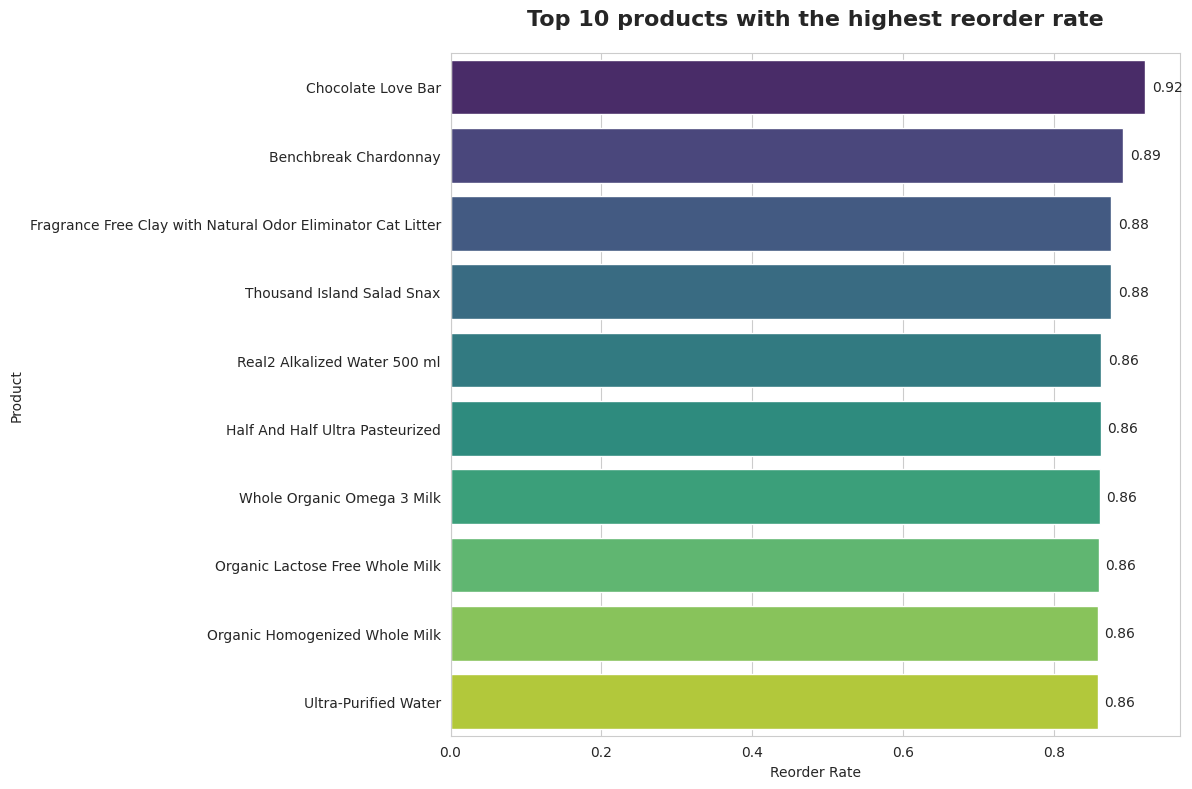

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load product information (product_id and product_name)
df_products = pd.read_csv(DATA_PATH + 'products.csv')

# Group by product_id and compute:
# - sum: total number of times the product was reordered
# - count: total number of times the product was purchased
# - mean: reorder rate (average of reordered column)
product_stats = df_prior.groupby('product_id').agg({
    'reordered': ['sum', 'count', 'mean']
})

# Rename columns for better readability
product_stats.columns = ['total_reorders', 'total_products', 'reorder_rate']

# Reset index to turn product_id back into a normal column
product_stats = product_stats.reset_index()

# Merge with product names to make the data more interpretable
product_features_final = product_stats.merge(
    df_products[['product_id', 'product_name']],  # select only necessary columns
    on='product_id',  # join on product_id
    how='left'  # keep all rows from product_stats
)

# Reorder columns for a clean structure
product_features_final = product_features_final[[
    'product_id',
    'product_name',
    'total_reorders',
    'total_products',
    'reorder_rate'
]]


# Filter products with enough observations (more than 100 purchases)
# Then:
# - sort by reorder_rate descending
# - take top 10 products
top_reorder = product_features_final[
    product_features_final['total_products'] > 100
].sort_values(by='reorder_rate', ascending=False).head(10)

# Set plot style
sns.set_style("whitegrid")

# Create figure with larger size
plt.figure(figsize=(12, 8))

# Create horizontal bar chart:
# - x-axis: reorder rate
# - y-axis: product names
ax = sns.barplot(
    x='reorder_rate',
    y='product_name',
    data=top_reorder,
    hue='product_name',   # assign different colors to each product
    palette='viridis',    # color palette
    legend=False          # no legend needed
)

# Add title and axis labels
ax.set_title('Top 10 products with the highest reorder rate', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Reorder Rate')
ax.set_ylabel('Product')

# Display values on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [5]:
pip install squarify

### 2. First-in-Basket Products

We identify products that are most frequently added first to the cart. These items often represent essential or habitual purchases.

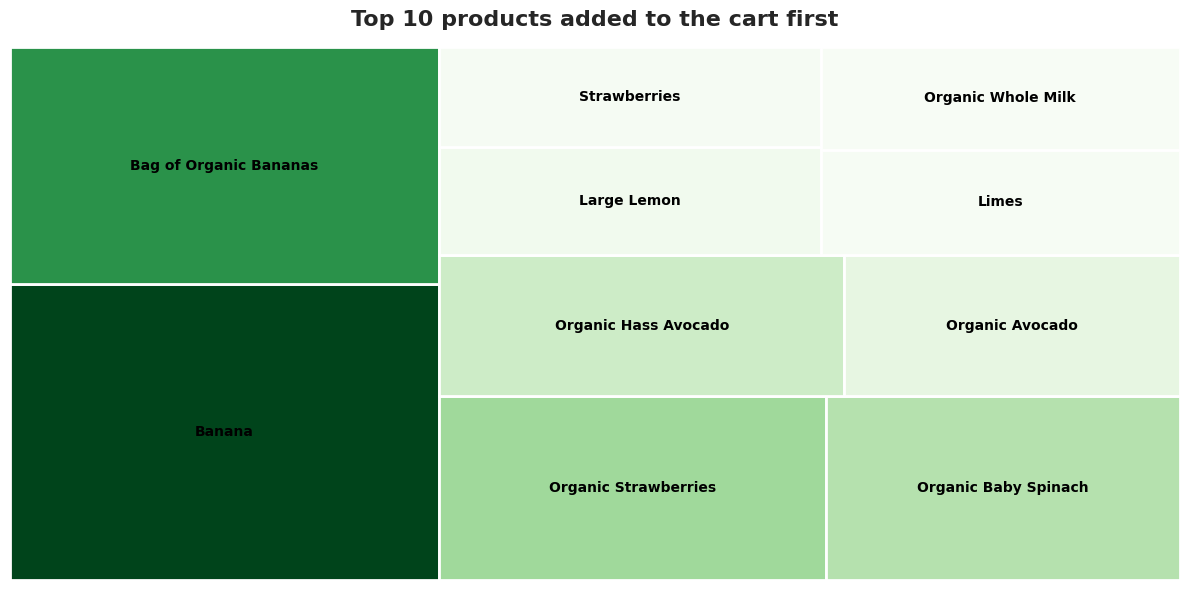

In [6]:
import squarify
import matplotlib.colors as mcolors

# 1. Load product catalog (CSV) and transaction data (Parquet)
df_products = pd.read_csv(DATA_PATH + 'products.csv')

# 2. Compute the "First Add-to-Cart Product" feature

# Step A: Count total number of purchases for each product from df_prior
total_counts = df_prior.groupby('product_id').size().reset_index(name='total_purchases')

# Step B: Filter rows where the product was added first in the cart (add_to_cart_order == 1)
first_orders = df_prior[df_prior['add_to_cart_order'] == 1]
first_counts = first_orders.groupby('product_id').size().reset_index(name='total_first_orders')

# Step C: Merge counts and calculate the ratio
first_to_cart_df = total_counts.merge(first_counts, on='product_id', how='left')
first_to_cart_df['total_first_orders'] = first_to_cart_df['total_first_orders'].fillna(0)

# Calculate first-to-cart rate = first orders / total purchases
first_to_cart_df['first_to_cart_rate'] = (
    first_to_cart_df['total_first_orders'] / first_to_cart_df['total_purchases']
).round(4)

# Step D: Merge with df_products to get product names
final_df = first_to_cart_df.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Reorder columns for clarity
final_df = final_df[
    ['product_id', 'product_name', 'total_first_orders', 'total_purchases', 'first_to_cart_rate']
]

# --- DRAW TREEMAP ---

# Select top 10 most purchased products
top_df = final_df.sort_values(by='total_purchases', ascending=False).head(10)

# Normalize colors (darker green = higher value)
norm = mcolors.Normalize(
    vmin=top_df['total_purchases'].min(),
    vmax=top_df['total_purchases'].max()
)

colors = plt.cm.Greens(norm(top_df['total_purchases']))

plt.figure(figsize=(12, 6))

# Create treemap
squarify.plot(
    sizes=top_df['total_purchases'],   # rectangle sizes based on total purchases
    label=top_df['product_name'],      # labels are product names
    color=colors,
    alpha=1,
    edgecolor='white',   # white borders between rectangles
    linewidth=2,
    text_kwargs={
        'fontsize': 10,
        'color': 'black',
        'weight': 'bold',
    }
)

plt.axis('off')  # remove axes
plt.title(
    'Top 10 products added to the cart first',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

### 3. User–Product Interaction Features

We construct interaction features between users and products, including:

- Purchase frequency: number of times a user bought a product  
- Recency: the most recent order containing the product  
- Reorder ratio: how often the product is repurchased relative to other items  

These features capture user preference and product importance at an individual level.

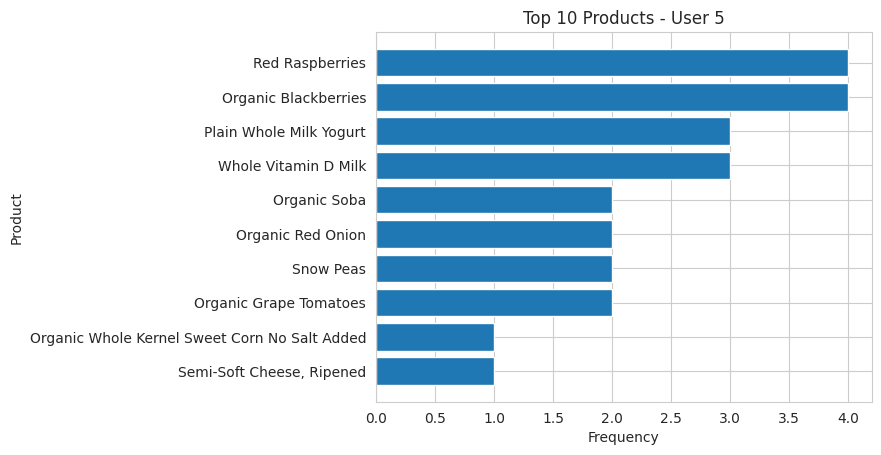


--- TOP PRODUCTS BY RECENCY  ---
                                 product_name  last_order_number
Organic Whole Kernel Sweet Corn No Salt Added                  4
              Large Organic Omega3 Brown Eggs                  4
                         Whole Vitamin D Milk                  4
                       Organic Grape Tomatoes                  4
                         Uncured Genoa Salami                  4
                         Organic Blackberries                  4
                      Plain Whole Milk Yogurt                  4
                    Semi-Soft Cheese, Ripened                  4
                                 Organic Soba                  4
                                    Snow Peas                  4

--- TOP PRODUCTS BY PREFERENCE  ---
                                 product_name  times_bought  purchase_ratio
                              Red Raspberries             4        0.108108
                         Organic Blackberries             4   

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. USER - PRODUCT FEATURES
# ================================

user_product = df_prior.groupby(['user_id', 'product_id']).agg(
    times_bought=('order_number', 'count'),        # Frequency
    last_order_number=('order_number', 'max')      # Recency
).reset_index()

# ================================
# 2. USER LEVEL
# ================================

user_total_items = df_prior.groupby('user_id').size().reset_index(name='user_total_items')
user_total_orders = df_prior.groupby('user_id')['order_number'].max().reset_index(name='user_total_orders')

user_product = user_product.merge(user_total_items, on='user_id')
user_product = user_product.merge(user_total_orders, on='user_id')

# ================================
# 3. METRICS
# ================================

# Preference
user_product['purchase_ratio'] = (
    user_product['times_bought'] / user_product['user_total_items']
)

# ================================
# 4. ADD PRODUCT NAME
# ================================

df_products = pd.read_csv(DATA_PATH + 'products.csv')

final_df = user_product.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# ================================
# 5. Choose user
# ================================

user_id = 5
user_data = final_df[final_df['user_id'] == user_id]

# ================================
# 6. Graph 1: TOP PRODUCTS
# ================================

top_products = user_data.sort_values(
    'times_bought', ascending=False
).head(10)

plt.figure()
plt.barh(top_products['product_name'], top_products['times_bought'])
plt.title(f'Top 10 Products - User {user_id}')
plt.xlabel('Frequency')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

# ================================
# 8. Board 2: RECENCY (Last bought)
# ================================

recency_table = user_data.sort_values(
    by='last_order_number', ascending=False
)[[
    'product_name',
    'last_order_number'
]].head(10)

print("\n--- TOP PRODUCTS BY RECENCY  ---")
print(recency_table.to_string(index=False))


# ================================
# 9. Board 3 : PREFERENCE (Percentage)
# ================================

preference_table = user_data.sort_values(
    by='purchase_ratio', ascending=False
)[[
    'product_name',
    'times_bought',
    'purchase_ratio'
]].head(10)

print("\n--- TOP PRODUCTS BY PREFERENCE  ---")
print(preference_table.to_string(index=False))


### 4. Exploratory Data Analysis

We visualize product and aisle popularity to better understand overall purchasing trends:

- Top 10 most popular products  
- Top 10 most popular aisles  


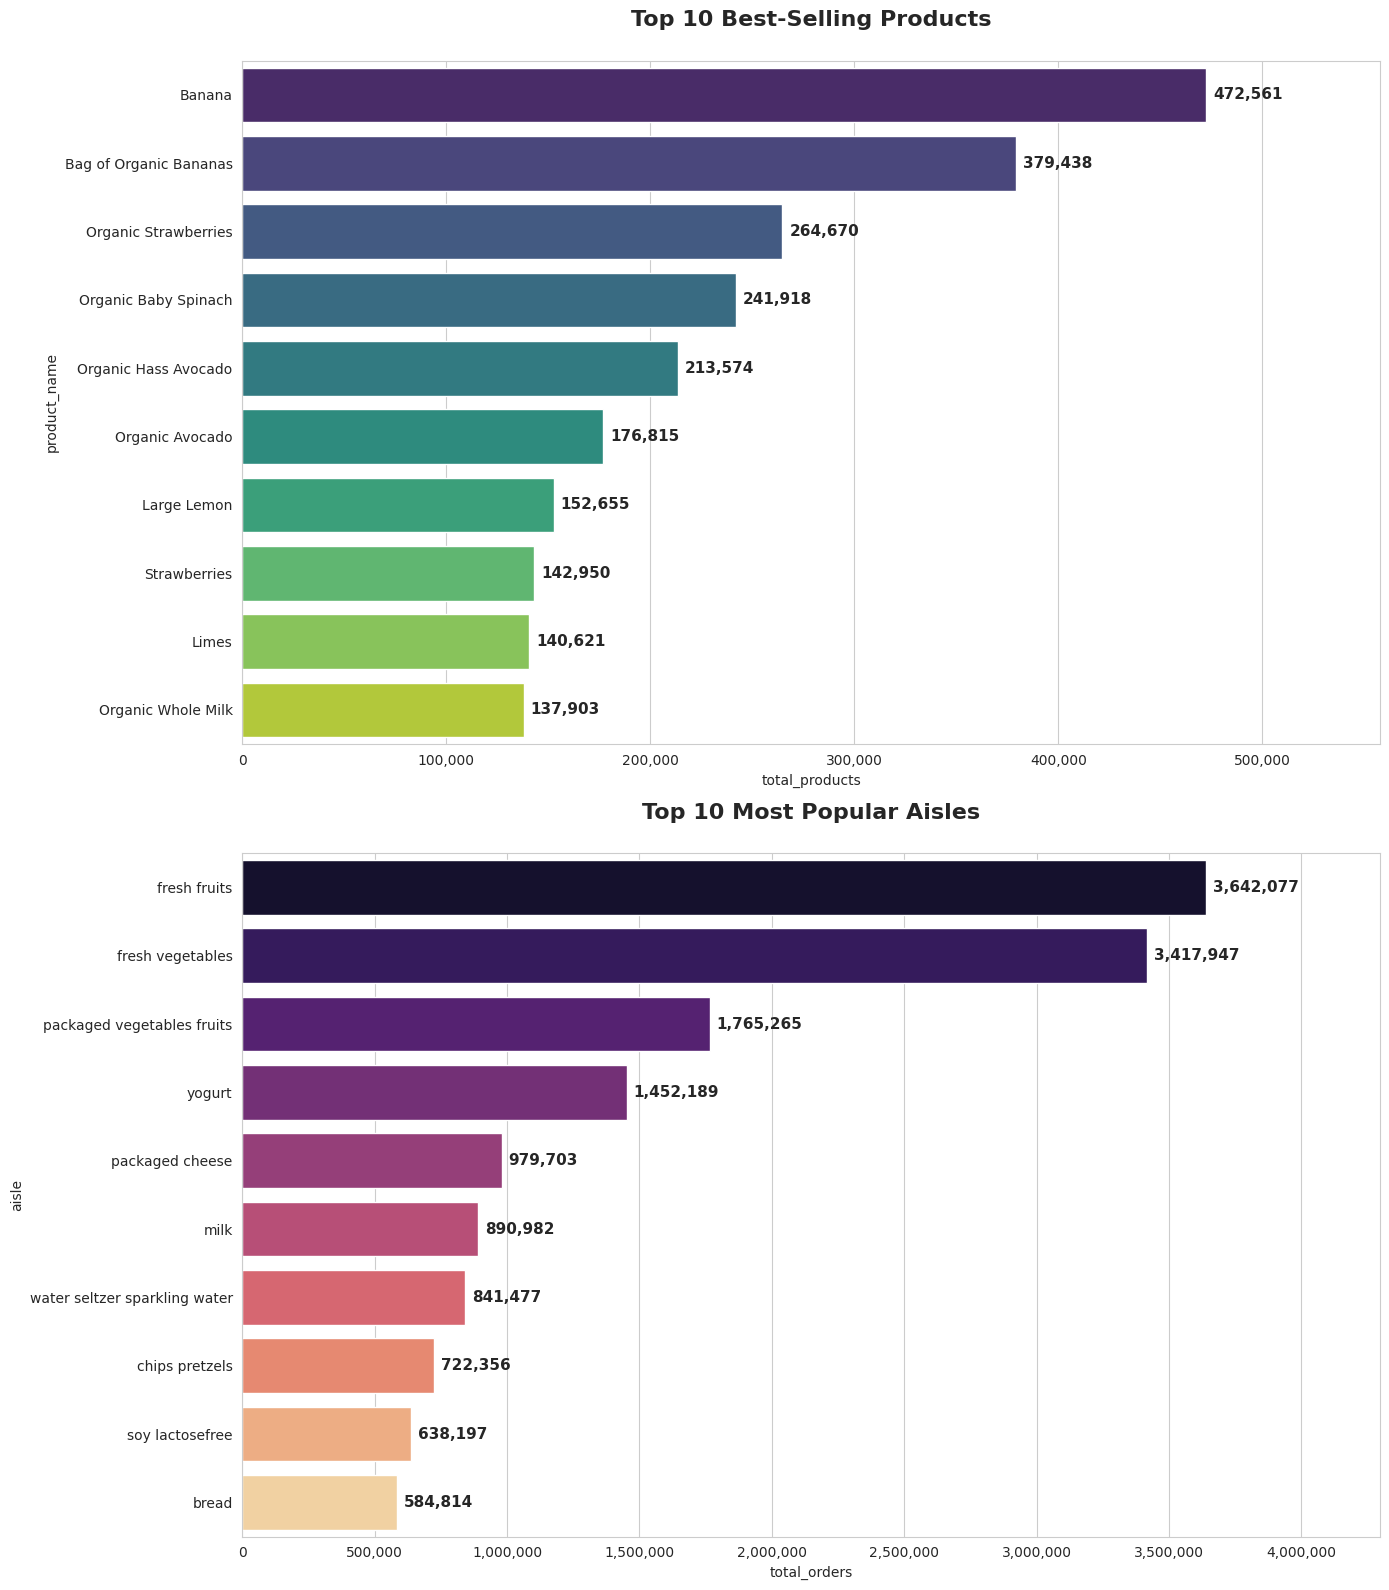

In [12]:
import matplotlib.ticker as ticker
df_aisles = pd.read_csv(DATA_PATH + 'aisles.csv')
# --- 1. DATA PROCESSING ---

# Count how many times each product appears (i.e., total purchases per product)
product_stats = df_prior.groupby('product_id').size().reset_index(name='total_products')

# Merge with product names to make the results readable
product_features_final = product_stats.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Select top 10 most purchased products
top_products = product_features_final.sort_values(
    by='total_products',
    ascending=False
).head(10)


# Merge df_prior with product aisle information
# This allows us to analyze purchases at the aisle (category) level
df_merged_aisle = df_prior[['product_id']].merge(
    df_products[['product_id', 'aisle_id']],
    on='product_id',
    how='left'
)

# Count total number of orders per aisle
aisle_stats = df_merged_aisle.groupby('aisle_id').size().reset_index(name='total_orders')

# Merge with aisle names for readability
aisle_final = aisle_stats.merge(df_aisles, on='aisle_id', how='left')

# Select top 10 most popular aisles
top_aisles = aisle_final.sort_values(
    by='total_orders',
    ascending=False
).head(10)


# --- 2. VISUALIZATION ---

# Set plot style
sns.set_style("whitegrid")

# Create a figure with 2 subplots (vertical layout)
fig, ax = plt.subplots(2, 1, figsize=(14, 16))


# --- CHART 1: Top Products ---
sns.barplot(
    x='total_products',
    y='product_name',
    data=top_products,
    ax=ax[0],
    hue='product_name',   # each product gets a different color
    palette='viridis',
    legend=False
)

# Set title
ax[0].set_title('Top 10 Best-Selling Products', fontsize=16, fontweight='bold', pad=25)

# Format x-axis numbers with commas (e.g., 10000 -> 10,000)
ax[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Add value labels to ALL bars (important fix)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold')


# --- CHART 2: Top Aisles ---
sns.barplot(
    x='total_orders',
    y='aisle',
    data=top_aisles,
    ax=ax[1],
    hue='aisle',   # each aisle gets a different color
    palette='magma',
    legend=False
)

# Set title
ax[1].set_title('Top 10 Most Popular Aisles', fontsize=16, fontweight='bold', pad=25)

# Format x-axis numbers with commas
ax[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Add value labels to ALL bars (important fix)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold')


# Expand x-axis limits slightly so labels are not cut off
ax[0].set_xlim(right=top_products['total_products'].max() * 1.18)
ax[1].set_xlim(right=top_aisles['total_orders'].max() * 1.18)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()